<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [35]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-24 09:25:39--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  31.4MB/s    in 6.0s    

2026-07-24 09:25:52 (33.5 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [36]:
!pip install pandas

In [37]:
!pip install matplotlib

In [38]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [39]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [40]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [41]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64
Outliers count: 5876
IQR: 190,000 | Lower bound: -225,000 | Upper: 535,000


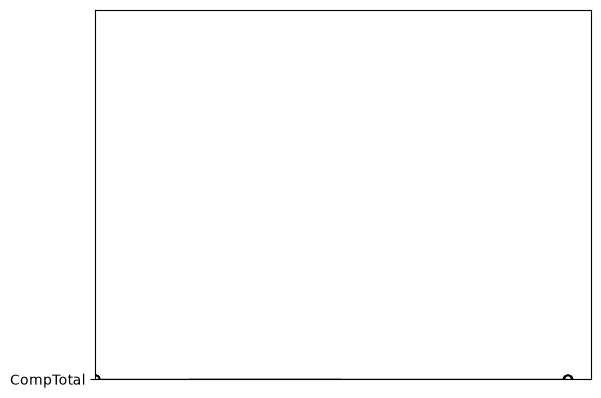

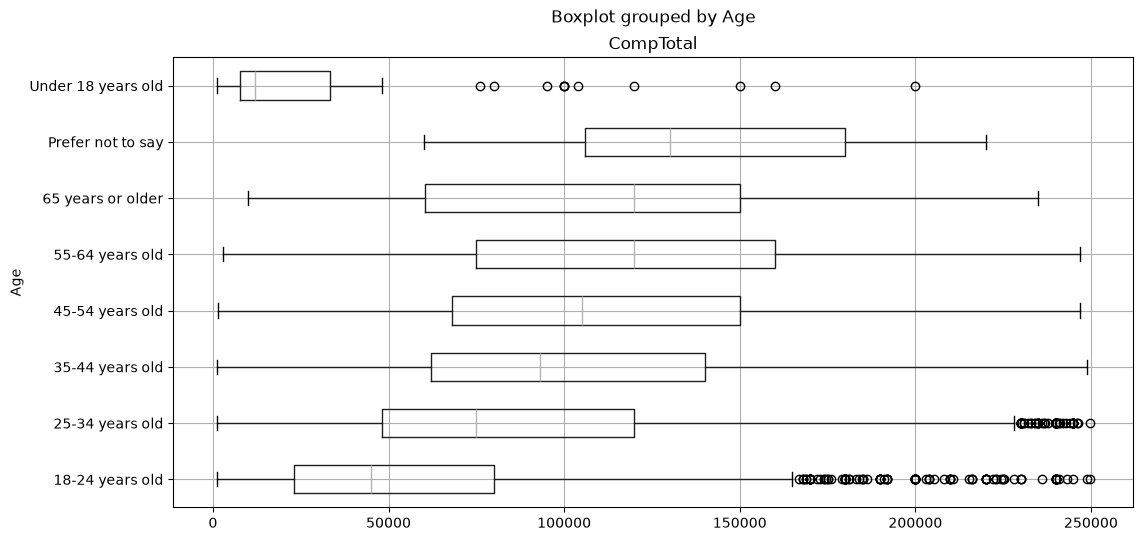

In [43]:
import pandas as pd

df = pd.read_csv("survey-data.csv")

# Clean
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# ---- 1. Simplest pandas boxplot ----
df.boxplot(column='CompTotal')
# plt.show() if not in Jupyter

# ---- 2. Filtered - Recommended (outliers are crazy in raw) ----
df_filtered = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 250000)]

df_filtered.boxplot(column='CompTotal', grid=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))

# ---- 3. Horizontal + styled ----
df_filtered.boxplot(column='CompTotal', vert=False, grid=True)

# ---- 4. Boxplot by group - e.g. CompTotal by Age (great for analysis) ----
df_filtered.boxplot(column='CompTotal', by='Age', figsize=(12,6), vert=False)
# Shows which Age group has most outliers

# ---- 5. Full analysis stats ----
print(df['CompTotal'].describe())
# Q1, Q3, IQR for outlier math
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['CompTotal'] < Q1 - 1.5*IQR) | (df['CompTotal'] > Q3 + 1.5*IQR)]
print(f"Outliers count: {len(outliers)}")
print(f"IQR: {IQR:,.0f} | Lower bound: {Q1 - 1.5*IQR:,.0f} | Upper: {Q3 + 1.5*IQR:,.0f}")

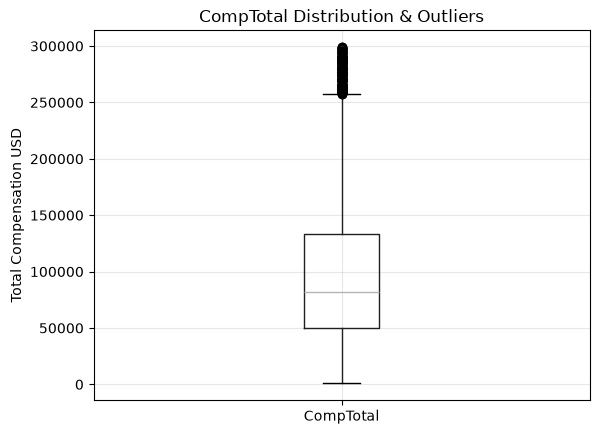

In [48]:
#simpler method
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Clean - convert to number
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Drop NaN and filter
df_clean = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 300000)]

# Pandas boxplot
df_clean.boxplot(column=['CompTotal'])

plt.title('CompTotal Distribution & Outliers')
plt.ylabel('Total Compensation USD')
plt.grid(True, alpha=0.3)

plt.show() # <-- you were missing this

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


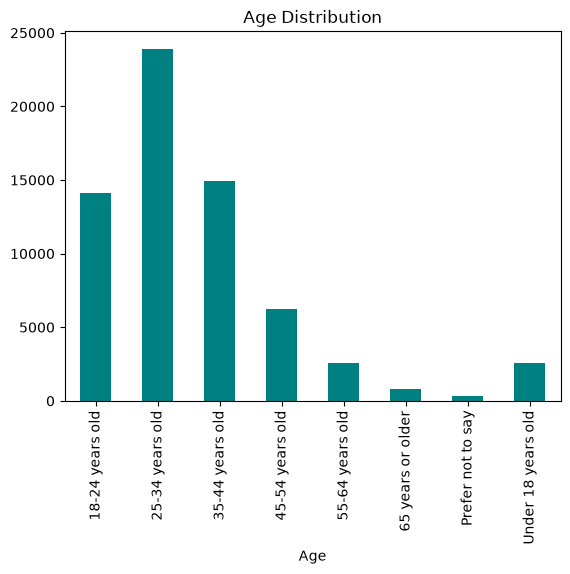

In [50]:
# your code goes here
# One-liner bar distribution
df['Age'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Age Distribution')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Axes: xlabel='Age'>

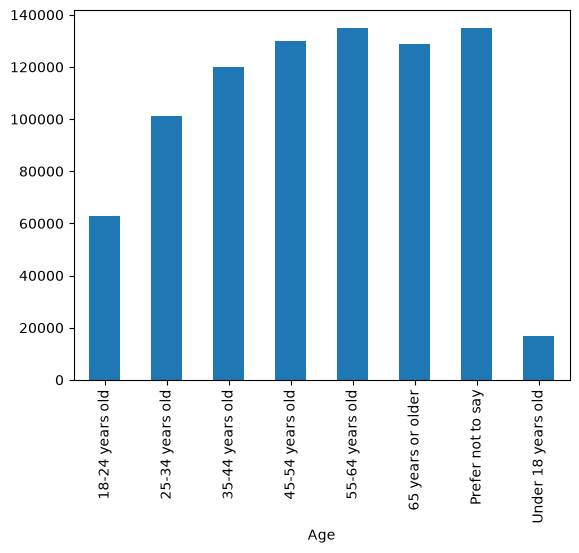

In [52]:
# your code goes here
df.groupby('Age')['CompTotal'].median().plot(kind='bar')

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


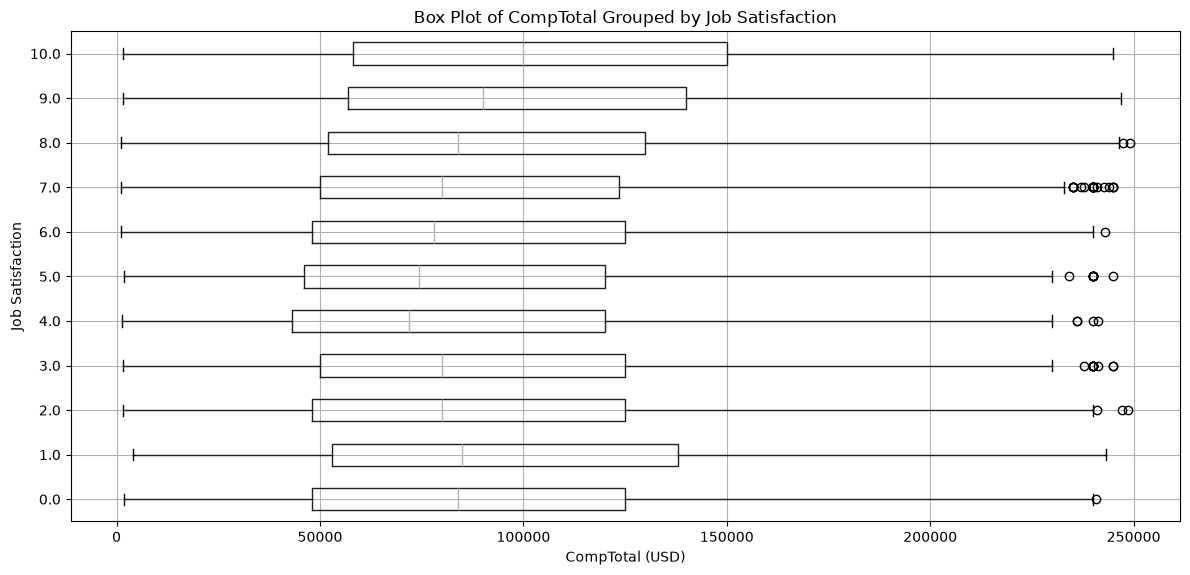

In [55]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("survey-data.csv")
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Filter to make plot readable
df = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 250000)]

# Box Plot of CompTotal by Job Satisfaction
df.boxplot(column='CompTotal', by='JobSat', figsize=(12,6), vert=False)

plt.title('Box Plot of CompTotal Grouped by Job Satisfaction')
plt.suptitle('')
plt.xlabel('CompTotal (USD)')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


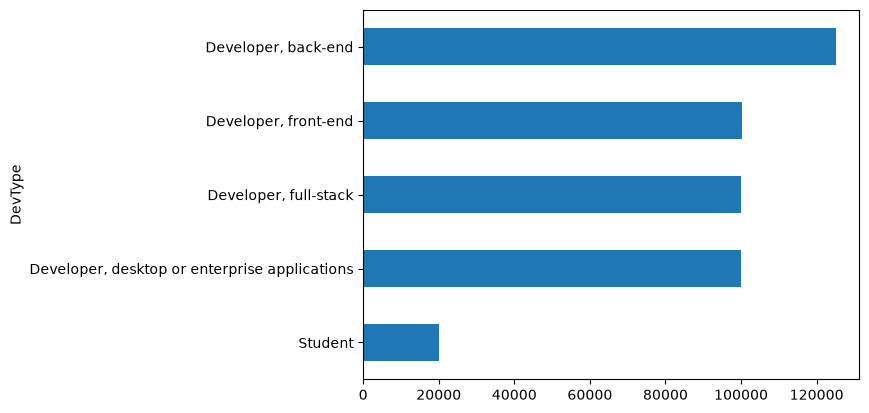

In [57]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("survey-data.csv")
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

top5 = df['DevType'].value_counts().head(5).index
df_top5 = df[df['DevType'].isin(top5)]

df_top5.groupby('DevType')['CompTotal'].median().sort_values().plot(kind='barh')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


<Axes: xlabel='Country'>

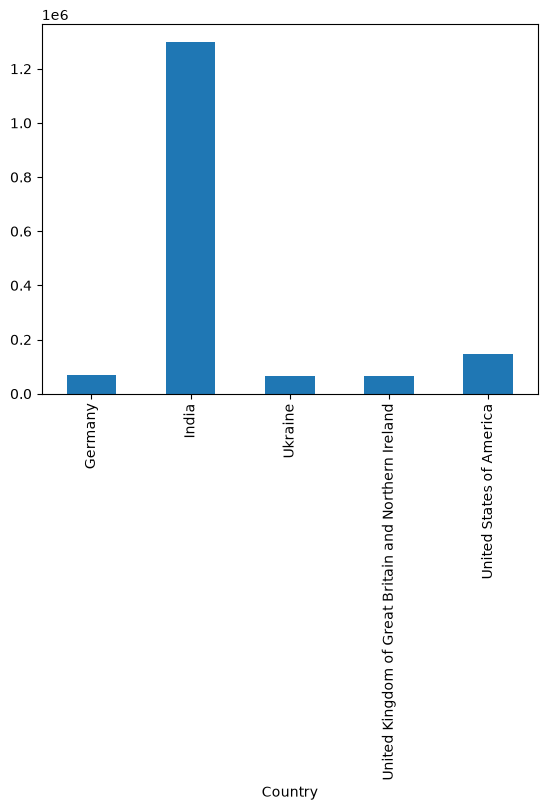

In [58]:
# your code goes here
import pandas as pd
df = pd.read_csv("survey-data.csv")

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
top5 = df['Country'].value_counts().head(5).index

df[df['Country'].isin(top5)].groupby('Country')['CompTotal'].median().plot(kind='bar')

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [ ]:
# your code goes here
import pandas as pd


import pandas as pd
df = pd.read_csv("survey-data.csv")

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 300000)]

df.groupby('Employment')['CompTotal'].median().sort_values().plot(kind='barh', logx=True)

<Axes: ylabel='Employment'>

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [ ]:
# your code goes here

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
